# Neural machine translation: LSTM only

In this demo, we build a English-French seq2seq translation model. Some of the key implementation details are:

1. **Subword tokenization** - Word-level tokenization creates massive vocabularies (50K+ words) and can't handle unseen words. We use SentencePiece to keep vocabulary manageable (~8K tokens) while handling any input.

2. **Real training data** - We use 100,000 sentence pairs from the OPUS-100 English-French corpus instead of 15 hand-crafted phrases.

3. **Bidirectional encoder** - Capture context from both directions for better source understanding.

4. **BLEU evaluation** - Translation quality is measured using BLEU (Bilingual Evaluation Understudy) score, which compares n-gram overlap between model outputs and reference translations. BLEU computes a score between 0 and 100 based on:
   - **N-gram precision**: How many n-grams (1-4 words) from the model output appear in the reference translation, averaged using geometric mean
   - **Brevity penalty**: Exponentially penalizes translations that are too short (which would otherwise artificially inflate precision)
   - **Corpus-level aggregation**: Combines statistics across many sentences for reliable evaluation
   
   BLEU scores above 60 indicate very high quality translation, 40-60 is good, 20-40 is mediocre, and below 20 is poor. While BLEU has limitations (e.g., doesn't capture meaning or fluency perfectly), it's fast, automated, and correlates reasonably well with human judgment, making it ideal for monitoring training progress.

### References

The encoder-decoder architecture for neural machine translation was introduced in:

> Sutskever, I., Vinyals, O., & Le, Q. V. (2014). **Sequence to sequence learning with neural networks.** *Advances in Neural Information Processing Systems, 27.* https://arxiv.org/abs/1409.3215

The OPUS-100 dataset used in this activity:

> Zhang, B., Williams, P., Titov, I., & Sennrich, R. (2020). **Improving massively multilingual neural machine translation and zero-shot translation.** *Proceedings of the 58th Annual Meeting of the Association for Computational Linguistics (ACL).* https://arxiv.org/abs/2004.11867

## Notebook set-up

### Imports

In [1]:
# Suppress TensorFlow warnings and select GPU
import logging
import os

# Environment variables for TensorFlow. Note: these must
# be set BEFORE importing TensorFlow to take effect.
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress TensorFlow warnings
os.environ['CUDA_VISIBLE_DEVICES'] = '1' # Select GPU, 0 for GPU 1, etc.

# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# NLP and translation libraries
from datasets import load_dataset
from sacrebleu.metrics import BLEU
from transformers import MarianTokenizer

# Keras model components
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Embedding,
    Bidirectional, Concatenate
)

### Configuration

In [2]:
# Configure GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# Disable Jupyter widgets to prevent rendering issues after reopening notebook
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '0'  # Keep progress bars but use plain text

# Set event level output filter for TensorFlow
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Initialization
np.random.seed(315)
tf.random.set_seed(315)

## 1. Prepare assets

Using the OPUS-100 English-French translation corpus from Hugging Face datasets with subword tokenization (SentencePiece). Subword tokenization is essential for NMT (Neural Machine Translation) because it:
- Keeps vocabulary manageable (~8K tokens vs 50K+ words)
- Handles rare/unseen words by breaking them into known subwords
- Shares subword units across related words (e.g., "play", "playing", "played")

### 1.1. Load tokenizer

In [3]:
# Load pre-trained subword tokenizer (SentencePiece)
# MarianTokenizer is specifically designed for the Helsinki-NLP translation models
tokenizer = MarianTokenizer.from_pretrained('Helsinki-NLP/opus-mt-en-fr')

print(f'Tokenizer vocabulary size: {tokenizer.vocab_size}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

# Example of subword tokenization
example = 'The neural network learned representations'
tokens = tokenizer.tokenize(example)
print(f'\nExample tokenization:')
print(f'  Input: "{example}"')
print(f'  Tokens: {tokens}')

Tokenizer vocabulary size: 59514
Special tokens: {'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}

Example tokenization:
  Input: "The neural network learned representations"
  Tokens: ['▁The', '▁ne', 'ural', '▁network', '▁learned', '▁representations']


### 1.2. Load dataset

In [4]:
# Load OPUS-100 English-French translation dataset
dataset = load_dataset('Helsinki-NLP/opus-100', 'en-fr')

# Extract translation pairs and filter by token length
pairs = []
MAX_SEQ_LENGTH = 20  # Maximum tokens per sentence

for item in dataset['train']:

    en_text = item['translation']['en'].strip()
    fr_text = item['translation']['fr'].strip()
    
    # Check token length using tokenize() to avoid truncation warnings
    en_tokens = tokenizer.tokenize(en_text)
    fr_tokens = tokenizer.tokenize(fr_text)
    
    if len(en_tokens) <= MAX_SEQ_LENGTH and len(fr_tokens) <= MAX_SEQ_LENGTH:
        pairs.append((en_text, fr_text))
    
    # Limit dataset size for reasonable training time
    if len(pairs) >= 100000:
        break

print(f'Loaded {len(pairs)} translation pairs')
print(f'\nSample pairs:')

for en, fr in pairs[1:5]:
    print()
    print(f'  EN: {en}')
    print(f'  FR: {fr}')

Loaded 100000 translation pairs

Sample pairs:

  EN: Hello, what's that?
  FR: Qu'est-ce que c'est que ça ?

  EN: And then I will teach you everything i know.
  FR: Et alors, je t'apprendrai tout ce que je sais.

  EN: Did you find something?
  FR: Par ici !

  EN: Article 6
  FR: Article 6


In [5]:
# Tokenize all pairs using the subword tokenizer
# The tokenizer handles both English and French (it's a multilingual SentencePiece model)
MAX_ENCODER_LEN = 22  # Slightly larger than MAX_SEQ_LENGTH for special tokens
MAX_DECODER_LEN = 24

# Tokenize source (English) sentences
encoder_inputs = tokenizer(
    [pair[0] for pair in pairs],
    padding='max_length',
    truncation=True,
    max_length=MAX_ENCODER_LEN,
    return_tensors='np'
)

# Tokenize target (French) sentences
decoder_input_texts = [pair[1] for pair in pairs]

decoder_inputs = tokenizer(
    decoder_input_texts,
    padding='max_length',
    truncation=True,
    max_length=MAX_DECODER_LEN - 1,  # Leave room for BOS token
    return_tensors='np'
)

# Prepare encoder data
encoder_input_data = encoder_inputs['input_ids']

# CRITICAL: Decoder input must start with BOS token (we use pad_token_id)
# This aligns training with inference, where we also start with pad_token_id
# decoder_input: [BOS, tok1, tok2, ..., tokN, pad, pad...]
# decoder_target: [tok1, tok2, ..., tokN, EOS, pad, pad...]
raw_decoder_tokens = decoder_inputs['input_ids']
decoder_input_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_input_data[:, 1:1 + raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Targets are the original tokens (what we want to predict after BOS)
decoder_target_data = np.full((len(pairs), MAX_DECODER_LEN), tokenizer.pad_token_id, dtype=np.int32)
decoder_target_data[:, :raw_decoder_tokens.shape[1]] = raw_decoder_tokens

# Model dimensions
num_samples = len(pairs)
num_tokens = tokenizer.vocab_size  # Same vocab for encoder and decoder
max_encoder_len = MAX_ENCODER_LEN
max_decoder_len = MAX_DECODER_LEN

print(f'Vocabulary size: {num_tokens}')
print(f'Max encoder length: {max_encoder_len}')
print(f'Max decoder length: {max_decoder_len}')
print(f'Training samples: {num_samples}')
print(f'\nEncoder input shape: {encoder_input_data.shape}')
print(f'Decoder input shape: {decoder_input_data.shape}')
print(f'Decoder target shape: {decoder_target_data.shape}')

Vocabulary size: 59514
Max encoder length: 22
Max decoder length: 24
Training samples: 100000

Encoder input shape: (100000, 22)
Decoder input shape: (100000, 24)
Decoder target shape: (100000, 24)


## 2. Model definitions

This section defines all model components needed for training and evaluation. We build:
1. **Training model**: The encoder-decoder architecture trained on parallel text
2. **Inference models**: Separate encoder and decoder for autoregressive translation
3. **Translation function**: Greedy decoding loop for generating translations
4. **BLEU callback**: Monitors translation quality during training

**Training architecture:**

```text
      ENCODER                                                 DECODER
                                                          
  Input: "Hello world"                               Target: "<s> Bonjour monde"
         │                                                       │
         ▼                                                       ▼
   ┌─────────────┐                                        ┌─────────────┐
   │  Embedding  │                                        │  Embedding  │
   └──────┬──────┘                                        └──────┬──────┘
          │                                                      │
          ▼                                                      ▼
  ┌───────────────┐       Context vector [h, c]           ┌─────────────┐
  │ Bidirectional │ ────────────────────────────────────► │    LSTM     │
  │     LSTM      │       (concatenated states)           └──────┬──────┘
  └───────────────┘                                              │
                                                                 ▼
                                                          ┌─────────────┐
                                                          │    Dense    │
                                                          │  (softmax)  │
                                                          └──────┬──────┘
                                                                 │
                                                                 ▼
                                                           Output sequence
                                                                 │
                                                    ┌────────────┴────────────┐
                                                    ▼                         ▼
                                         Labels (shifted target)         Predictions
                                          "Bonjour monde </s>"       "Bonjour monde </s>"
                                                    │                         │
                                                    └─────────► Loss ◄────────┘
```

### 2.1. Training model

The training model uses teacher forcing: at each decoder step, it receives the ground truth previous token rather than its own prediction. This allows parallel computation of the entire output sequence but requires a different architecture for inference.

In [6]:
# Import model building function from src module
import sys
sys.path.append('..')

from src import build_bidirectional_model

# Build the training model
model = build_bidirectional_model(num_tokens, max_encoder_len, max_decoder_len, latent_dim=256)

### 2.2. Inference models

During inference, we generate translations one token at a time using the decoder's own predictions. This requires restructuring the model into separate encoder and decoder components:
- The **encoder model** processes the input sentence once and returns the hidden states
- The **decoder model** takes a single token and the previous states, outputting the next token probabilities and updated states

This separation allows the autoregressive decoding loop where each predicted token feeds back as input.

In [7]:
# Import inference model builder from src module
from src import build_inference_models_lstm

### 2.3. Translation function

The translation function implements greedy decoding: at each step, it selects the token with the highest probability. While beam search would produce better translations, greedy decoding is faster and sufficient for monitoring training progress.

In [8]:
# Import translate function from src module
from src import translate_lstm

### 2.4. BLEU score callback

The BLEU (Bilingual Evaluation Understudy) score measures translation quality by comparing n-gram overlap between the model's output and reference translations. Since BLEU requires actual translations, the callback must:
1. **Build inference models** from the current training model weights at each epoch
2. **Generate translations** using the translation function's autoregressive decoding
3. **Compute BLEU** on a sample of the training pairs

The callback implements **model checkpointing** based on BLEU score, saving the weights whenever BLEU improves and restoring them at the end of training. This ensures we keep the best-translating model even if the model overfits in later epochs (which we expect to see in the learning curves).

In [9]:
# Import BLEU callback from src module
from src import BLEUCallback

# Create callback with updated signature
bleu_callback = BLEUCallback(
    pairs=pairs,
    tokenizer=tokenizer,
    max_encoder_len=max_encoder_len,
    max_decoder_len=max_decoder_len,
    translate_fn=translate_lstm,
    build_inference_fn=build_inference_models_lstm,
    sample_size=100,
    latent_dim=256,
    restore_best_weights=True
)

## 3. Model training

### 3.1. Build

In [10]:
model = build_bidirectional_model(num_tokens, max_encoder_len, max_decoder_len, latent_dim=256)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 22)]                 0         []                            
                                                                                                  
 encoder_embedding (Embeddi  (None, 22, 256)              1523558   ['encoder_input[0][0]']       
 ng)                                                      4                                       
                                                                                                  
 decoder_input (InputLayer)  [(None, 24)]                 0         []                            
                                                                                                  
 bidirectional_encoder (Bid  [(None, 512),                1050624   ['encoder_embedding[0][0

### 3.2. Train

In [11]:
%%time

import os
from datetime import datetime
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard

# Create directories for checkpoints and logs
checkpoint_dir = '../models/checkpoints/lstm'
log_dir = '../logs/lstm'
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

# Model checkpoint callback - saves best model based on validation loss
checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'model_epoch_{epoch:02d}_val_loss_{val_loss:.4f}.h5'),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# TensorBoard callback for training visualization
tensorboard_callback = TensorBoard(
    log_dir=os.path.join(log_dir, datetime.now().strftime('%Y%m%d-%H%M%S')),
    histogram_freq=1,
    write_graph=True,
    write_images=False,
    update_freq='epoch'
)

# Train the model with all callbacks
history = model.fit(
    [encoder_input_data, decoder_input_data],
    decoder_target_data,
    batch_size=32,
    epochs=15,
    validation_split=0.1,
    verbose=1,
    callbacks=[bleu_callback, checkpoint_callback, tensorboard_callback]
)

print(f'\nFinal training loss: {history.history["loss"][-1]:.4f}')
print(f'Final validation loss: {history.history["val_loss"][-1]:.4f}')
print(f'Best BLEU score: {bleu_callback.best_bleu:.2f}\n')

Epoch 1/15


I0000 00:00:1772657060.922589 3590903 service.cc:145] XLA service 0x7e34d05458a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772657060.922635 3590903 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
I0000 00:00:1772657061.033175 3590903 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2813/2813 [==============================] - ETA: 0s - loss: 2.2574 - accuracy: 0.6459 - BLEU: 3.08 (best)

Epoch 1: val_loss improved from inf to 1.74907, saving model to ../models/checkpoints/lstm/model_epoch_01_val_loss_1.7491.h5
2813/2813 [==============================] - 1078s 366ms/step - loss: 2.2574 - accuracy: 0.6459 - val_loss: 1.7491 - val_accuracy: 0.7013 - bleu_score: 3.0841
Epoch 2/15
2813/2813 [==============================] - ETA: 0s - loss: 1.5856 - accuracy: 0.7180 - BLEU: 3.69 (best)

Epoch 2: val_loss improved from 1.74907 to 1.53012, saving model to ../models/checkpoints/lstm/model_epoch_02_val_loss_1.5301.h5
2813/2813 [==============================] - 1017s 362ms/step - loss: 1.5856 - accuracy: 0.7180 - val_loss: 1.5301 - val_accuracy: 0.7300 - bleu_score: 3.6851
Epoch 3/15
2813/2813 [==============================] - ETA: 0s - loss: 1.3648 - accuracy: 0.7421 - BLEU: 6.73 (best)

Epoch 3: val_loss improved from 1.53012 to 1.44873, saving model to ../models/chec

### 3.3. Learning curves

**Viewing TensorBoard logs:** To visualize training metrics (loss, accuracy, BLEU score) in TensorBoard, run:
```bash
tensorboard --logdir ../logs/lstm
```
Then open the provided URL in your browser.

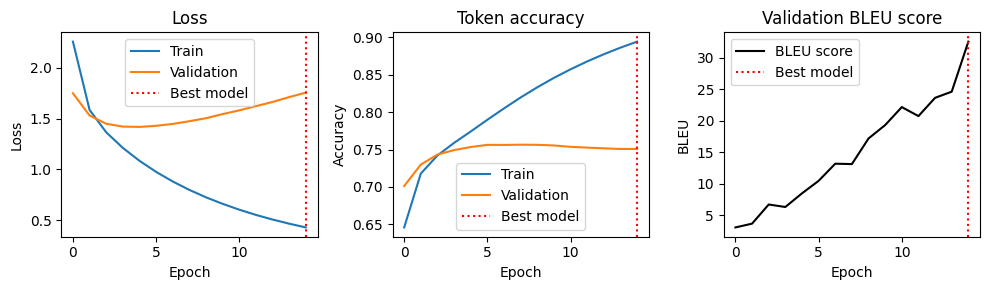

In [12]:
# Plot learning curves: loss, accuracy, and BLEU
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

# Epoch where best BLEU was achieved (model weights restored from here)
best_epoch = bleu_callback.best_epoch

# Left plot: training vs validation loss
# Overfitting visible when validation loss increases while training loss decreases
axes[0].set_title('Loss')
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(loc='best')

# Middle plot: token-level accuracy
# Shows fraction of correctly predicted tokens (inflated by padding tokens)
axes[1].set_title('Token accuracy')
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

# Right plot: BLEU score over training
# Marker shows best checkpoint (weights restored from this epoch)
axes[2].set_title('Validation BLEU score')
axes[2].plot(bleu_callback.bleu_scores, c='black', label='BLEU score')
axes[2].axvline(x=best_epoch, color='red', linestyle=':', label='Best model')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('BLEU')
axes[2].legend(loc='best')

plt.tight_layout()
plt.show()

**Note:** The loss and accuracy curves show clear overfitting (validation plateaus while training improves), yet BLEU continues to increase. Why?

- **Loss/accuracy** are computed using **teacher forcing** - the model sees ground truth previous tokens
- **BLEU** evaluates **autoregressive generation** - the model sees its own predictions

These are fundamentally different tasks. A model can memorize training sequences (overfitting the teacher-forcing objective) while its ability to generate coherent translations continues improving as embeddings become richer and general translation patterns solidify.

## 4. Translation examples and detailed evaluation

For inference, we split the model into separate encoder and decoder models. The encoder runs once to produce the initial states, then the decoder runs autoregressively, feeding each predicted token back as input.

**Inference architecture:**

```text

  STEP 1: Encode (run once)                     STEP 2: Decode token by token

  Input: "Hello world"                                 ┌─────────────┐
          │                           t=0: <pad> ─────►│  Embedding  │
          ▼                                            └──────┬──────┘
   ┌─────────────┐                                            │
   │  Embedding  │                                            ▼
   └──────┬──────┘                                     ┌─────────────┐
          │                           [h₀,c₀] ────────►│    LSTM     │───► [h₁,c₁]
          ▼                                            └──────┬──────┘
  ┌───────────────┐                                           │
  │ Bidirectional │                                           ▼
  │     LSTM      │                                    ┌─────────────┐
  └───────┬───────┘                                    │   Dense     │───► "Bonjour"
          │                                            └─────────────┘
          ▼
      [h₀, c₀]

  t=0: <pad>     ──► Embedding ──► LSTM ──► Dense ──► "Bonjour" (using h₀,c₀)
  t=1: "Bonjour" ──► Embedding ──► LSTM ──► Dense ──► "monde"   (using h₁,c₁)
  t=2: "monde"   ──► Embedding ──► LSTM ──► Dense ──► </s>      (stop)
```

The decoder model takes one token at a time and outputs the next token prediction plus updated states. We repeat until the model outputs an end-of-sequence token or reaches the maximum length.

In [13]:
# Build final inference models for translation examples
encoder_model, decoder_model = build_inference_models_lstm(model, latent_dim=256)

# Test translation on sample sentences
test_sentences = [
    'Hello, how are you?',
    'I love programming.',
    'The weather is nice today.'
]

print('Sample translations:')

for sent in test_sentences:

    print(f'  EN: {sent}')
    print(f'  FR: {translate_lstm(sent, encoder_model, decoder_model, tokenizer, max_encoder_len, max_decoder_len)}\n')

Sample translations:
  EN: Hello, how are you?
  FR: - Salut, comment ça va ?

  EN: I love programming.
  FR: J'adore les citoyens.

  EN: The weather is nice today.
  FR: C'est le bon moment.



### 4.1. Evaluate translations

In [14]:
# Evaluate on a larger sample than used during training callback
np.random.seed(315)
sample_indices = np.random.choice(len(pairs), size=min(200, len(pairs)), replace=False)

# Collect model predictions and ground truth
hypotheses = []  # Model translations
references = []  # Ground truth translations

print('Generating translations for BLEU evaluation...')

for i, idx in enumerate(sample_indices):

    en_text, fr_ref = pairs[idx]
    fr_hyp = translate_lstm(en_text, encoder_model, decoder_model, tokenizer, max_encoder_len, max_decoder_len)
    
    hypotheses.append(fr_hyp)
    references.append(fr_ref)
    
    # Progress indicator
    if (i + 1) % 50 == 0:
        print(f'  Processed {i + 1}/{len(sample_indices)} samples')

# Compute corpus-level BLEU (aggregates n-gram precision across all sentences)
bleu = BLEU()
result = bleu.corpus_score(hypotheses, [references])

print(f'\nBLEU score: {result.score:.2f}')
print(f'Breakdown: {result}')

# Qualitative analysis: inspect individual translations
print('\nSample predictions vs references:')

for i in range(5):

    print(f'  Source: {pairs[sample_indices[i]][0]}')
    print(f'  Reference: {references[i]}')
    print(f'  Hypothesis: {hypotheses[i]}\n')

Generating translations for BLEU evaluation...
  Processed 50/200 samples
  Processed 100/200 samples
  Processed 150/200 samples
  Processed 200/200 samples

BLEU score: 29.80
Breakdown: BLEU = 29.80 54.4/32.5/24.3/19.1 (BP = 0.989 ratio = 0.990 hyp_len = 1231 ref_len = 1244)

Sample predictions vs references:
  Source: - Your daughter.
  Reference: Votre fille.
  Hypothesis: Votre fille.

  Source: - I'm doing it for you!
  Reference: Il faut que tu en parles à tes parents.
  Hypothesis: - Je te l'ai fait !

  Source: http://www.eclaireurs.org
  Reference: http://scouts.montigny.free.fr
  Hypothesis: http://www.sse.es

  Source: Are you deaf? !
  Reference: T'es sourde ?
  Hypothesis: T'es fou ?

  Source: My poorfellow, it seems we aren't much different.
  Reference: Nous sommes logés à la même enseigne, mon vieux.
  Hypothesis: Nous sommes logés à ne pas avoir 40 ans.



## 5. Save and upload model to Hugging Face

Save the trained model and upload it to Hugging Face Hub for sharing and reuse.

In [15]:
import os
from huggingface_hub import HfApi, create_repo
from dotenv import load_dotenv

# Load Hugging Face token from .env file
load_dotenv()
hf_token = os.getenv('HF_TOKEN')

# Set repository name
repo_name = 'gperdrizet/english-french-LSTM'

# Create local directory for model artifacts
model_dir = '../models/english-french-LSTM'
os.makedirs(model_dir, exist_ok=True)

# Save the trained model weights
model.save_weights(os.path.join(model_dir, 'model_weights.h5'))
print(f'Model weights saved to {model_dir}')

# Save model configuration and metadata
import json

model_config = {
    'architecture': 'encoder-decoder-LSTM',
    'latent_dim': 256,
    'vocab_size': num_tokens,
    'max_encoder_len': max_encoder_len,
    'max_decoder_len': max_decoder_len,
    'num_samples': num_samples,
    'tokenizer': 'Helsinki-NLP/opus-mt-en-fr',
    'best_bleu': float(bleu_callback.best_bleu),
    'best_epoch': int(bleu_callback.best_epoch)
}

with open(os.path.join(model_dir, 'config.json'), 'w') as f:
    json.dump(model_config, f, indent=2)

print(f'Model configuration saved')

# Create README with model information
readme_content = f"""---
language:
- en
- fr
tags:
- translation
- seq2seq
- lstm
- neural-machine-translation
license: apache-2.0
---

# English-French Neural Machine Translation (LSTM)

This model is an encoder-decoder architecture with bidirectional LSTM for English to French translation.

## Model Details

- **Architecture**: Bidirectional LSTM encoder + LSTM decoder
- **Latent dimension**: {model_config['latent_dim']}
- **Vocabulary size**: {model_config['vocab_size']} tokens
- **Tokenizer**: MarianTokenizer (Helsinki-NLP/opus-mt-en-fr)
- **Training samples**: {model_config['num_samples']:,}
- **Best BLEU score**: {model_config['best_bleu']:.2f}

## Training Data

Trained on the OPUS-100 English-French parallel corpus, filtered to sentences with ≤20 tokens.

## Usage

Load the model weights and use with the `build_bidirectional_model()` and `build_inference_models()` functions from the training notebook.

## Limitations

- Maximum input length: {model_config['max_encoder_len']} tokens
- Maximum output length: {model_config['max_decoder_len']} tokens
- Greedy decoding (no beam search)
- Best suited for short sentences similar to training data
"""

with open(os.path.join(model_dir, 'README.md'), 'w') as f:
    f.write(readme_content)

print(f'README created')

# Upload to Hugging Face Hub
try:
    api = HfApi()
    
    # Create repository if it doesn't exist
    create_repo(repo_name, token=hf_token, exist_ok=True, repo_type='model')
    
    print(f'Uploading to {repo_name}...')
    
    # Upload all files in the model directory
    api.upload_folder(
        folder_path=model_dir,
        repo_id=repo_name,
        token=hf_token,
        repo_type='model'
    )
    
    print(f'Model successfully uploaded to https://huggingface.co/{repo_name}')

except Exception as e:
    print(f'Error uploading to Hugging Face: {e}')

Model weights saved to ../models/english-french-LSTM
Model configuration saved
README created
Uploading to gperdrizet/english-french-LSTM...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model successfully uploaded to https://huggingface.co/gperdrizet/english-french-LSTM
